# Copula Analysis: Tail Dependence Between CDS and DD

Design:
- Variables: weekly Δln(CDS) and Δ(−DD) to remove levels/trends
- Pool all observations by group × model → 6 fits
- Fit Gumbel, Clayton, Frank by MLE; compare AIC
- Primary result: upper tail dependence λ_U from Gumbel
- Expected: M0 exporters ≈ M0 controls; M1/M2 exporters > M1/M2 controls

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import rankdata, norm
from scipy.optimize import minimize_scalar, minimize
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.serif'] = ['Times New Roman']
matplotlib.rcParams['font.size'] = 8

In [3]:
# ── Paths ──────────────────────────────────────────────────────────────────
GAMMA = 15  # change to 5 or 25 for robustness
RESULTS_PATH = f'../output/Current_results/complete_results_weekly_{GAMMA}_dampening.csv'

# Column names — adjust if yours differ
DATE_COL    = 'date'
COUNTRY_COL = 'country'
CDS_COL     = 'cds_spread'   # observed 5Y CDS in bps
DD_COLS     = {'M0': 'DD_M0', 'M1': 'DD_M1', 'M2': 'DD_M2'}

In [4]:
# ── Country groups ─────────────────────────────────────────────────────────
EXPORTERS = ['Saudi Arabia', 'UAE (Abu Dhabi)', 'Colombia', 'Mexico',
             'Brazil', 'Egypt', 'Malaysia', 'Qatar']
CONTROLS  = ['Chile', 'China', 'Indonesia', 'Philippines',
             'South Africa', 'South Korea', 'Thailand', 'Turkey']

In [5]:
# ── Load data ───────────────────────────────────────────────────────────────
df = pd.read_csv(RESULTS_PATH, parse_dates=[DATE_COL])
df = df.sort_values([COUNTRY_COL, DATE_COL]).reset_index(drop=True)
print(df.shape)
print(df.columns.tolist())
df.head(3)

(8352, 26)
['date', 'country', 'cds_spread', 'risk_free_rate', 'B_f', 'LCL_usd', 'sigma_lcl', 'implied_V_M0', 'implied_sigma_V_M0', 'cca_converged_M0', 'implied_V_M1', 'implied_sigma_V_M1', 'cca_converged_M1', 'convenience_yield', 'implied_V_M2', 'implied_sigma_V_M2', 'cca_converged_M2', 'lambda_annual', 'group', 'exporter', 'DD_M0', 'DD_M1', 'DD_M2', 'PD_M0', 'PD_M1', 'PD_M2']


,date,country,cds_spread,risk_free_rate,B_f,LCL_usd,sigma_lcl,implied_V_M0,implied_sigma_V_M0,cca_converged_M0,...,cca_converged_M2,lambda_annual,group,exporter,DD_M0,DD_M1,DD_M2,PD_M0,PD_M1,PD_M2
0,2015-01-04,Brazil,207.97,0.0255,631.8961,792.778598,0.156749,1349.032253,0.092116,True,...,True,8.155143,Exporter,1.0,4.198043,3.634887,3.178353,0.000013,0.000139,0.000741
1,2015-01-11,Brazil,201.92,0.0255,631.8961,812.065172,0.158278,1368.318794,0.093935,True,...,True,7.705558,Exporter,1.0,4.180310,3.529999,3.223647,0.000015,0.000208,0.000633
2,2015-01-18,Brazil,205.65,0.0255,631.8961,814.905830,0.158203,1371.159461,0.094024,True,...,True,8.384939,Exporter,1.0,4.186038,3.612942,3.167098,0.000014,0.000151,0.000770


In [6]:
# ── Compute weekly changes ──────────────────────────────────────────────────
# Δln(CDS) and Δ(−DD) = −ΔDD
# Both increase when credit stress worsens → positive dependence in stress

df['ln_cds'] = np.log(df[CDS_COL])

for m, col in DD_COLS.items():
    df[f'dln_cds']       = df.groupby(COUNTRY_COL)['ln_cds'].diff()
    df[f'd_neg_dd_{m}']  = -df.groupby(COUNTRY_COL)[col].diff()   # Δ(−DD)

# Drop first obs per country (NaN from diff)
df = df.dropna(subset=['dln_cds', 'd_neg_dd_M0', 'd_neg_dd_M1', 'd_neg_dd_M2'])
print(f'Observations after differencing: {len(df)}')

Observations after differencing: 8336


In [7]:
# ── Pseudo-uniform transform ────────────────────────────────────────────────
def pseudo_uniform(x):
    """Rank-based pseudo-uniform on (0,1). Applied per pool."""
    n = len(x)
    return rankdata(x) / (n + 1)

def get_pool(group_countries, model):
    """Pool all country-weeks for a group, return pseudo-uniforms (u, v)."""
    mask = df[COUNTRY_COL].isin(group_countries)
    sub  = df.loc[mask, ['dln_cds', f'd_neg_dd_{model}']].dropna()
    u = pseudo_uniform(sub['dln_cds'].values)
    v = pseudo_uniform(sub[f'd_neg_dd_{model}'].values)
    return u, v

In [8]:
# ── Copula log-likelihoods ──────────────────────────────────────────────────

def gumbel_loglik(u, v, theta):
    """Gumbel copula log-likelihood. theta >= 1."""
    if theta < 1 + 1e-6:
        return -np.inf
    lu = -np.log(np.clip(u, 1e-10, 1-1e-10))
    lv = -np.log(np.clip(v, 1e-10, 1-1e-10))
    A  = (lu**theta + lv**theta)
    # log C(u,v)
    log_C = -A**(1/theta)
    # log density
    log_c = (log_C
             + (1/theta - 2) * np.log(A)
             + (theta - 1) * (np.log(lu) + np.log(lv))
             - np.log(u) - np.log(v)
             + np.log(A**(-1/theta) + theta - 1))
    return np.sum(log_c)

def clayton_loglik(u, v, theta):
    """Clayton copula log-likelihood. theta > 0."""
    if theta < 1e-6:
        return -np.inf
    u = np.clip(u, 1e-10, 1-1e-10)
    v = np.clip(v, 1e-10, 1-1e-10)
    log_c = (np.log(1 + theta)
             - (1 + theta) * np.log(u)
             - (1 + theta) * np.log(v)
             + (-(2 + 1/theta)) * np.log(u**(-theta) + v**(-theta) - 1))
    return np.sum(log_c)

def frank_loglik(u, v, theta):
    """Frank copula log-likelihood. theta != 0."""
    if abs(theta) < 1e-6:
        return -np.inf
    u = np.clip(u, 1e-10, 1-1e-10)
    v = np.clip(v, 1e-10, 1-1e-10)
    et  = np.exp(-theta)
    etu = np.exp(-theta * u)
    etv = np.exp(-theta * v)
    num = theta * (et - 1) * np.exp(-theta * (u + v))
    den = ((et - 1) + (etu - 1) * (etv - 1))**2
    log_c = np.log(np.clip(num / den, 1e-300, None))
    return np.sum(log_c)

In [9]:
# ── Fitting functions ───────────────────────────────────────────────────────

def fit_gumbel(u, v):
    res = minimize_scalar(lambda th: -gumbel_loglik(u, v, th),
                          bounds=(1.001, 20), method='bounded')
    theta = res.x
    ll    = -res.fun
    aic   = -2 * ll + 2
    tail  = 2 - 2**(1/theta)          # upper tail dependence
    return dict(family='Gumbel', theta=theta, loglik=ll, AIC=aic, tail_dep=tail)

def fit_clayton(u, v):
    res = minimize_scalar(lambda th: -clayton_loglik(u, v, th),
                          bounds=(0.001, 30), method='bounded')
    theta = res.x
    ll    = -res.fun
    aic   = -2 * ll + 2
    tail  = 2**(-1/theta)             # lower tail dependence
    return dict(family='Clayton', theta=theta, loglik=ll, AIC=aic, tail_dep=tail)

def fit_frank(u, v):
    res = minimize_scalar(lambda th: -frank_loglik(u, v, th),
                          bounds=(0.01, 30), method='bounded')
    theta = res.x
    ll    = -res.fun
    aic   = -2 * ll + 2
    return dict(family='Frank', theta=theta, loglik=ll, AIC=aic, tail_dep=0.0)

def fit_all(u, v):
    g = fit_gumbel(u, v)
    c = fit_clayton(u, v)
    f = fit_frank(u, v)
    best_aic = min(g['AIC'], c['AIC'], f['AIC'])
    for d in [g, c, f]:
        d['best'] = (d['AIC'] == best_aic)
    return g, c, f

In [10]:
# ── Run fits: 2 groups × 3 models ──────────────────────────────────────────
groups  = {'Exporter': EXPORTERS, 'Control': CONTROLS}
models  = ['M0', 'M1', 'M2']

results = []
fits_store = {}   # store (u, v, gumbel_fit) for plotting

for group_name, countries in groups.items():
    for model in models:
        u, v = get_pool(countries, model)
        g, c, f = fit_all(u, v)
        fits_store[(group_name, model)] = (u, v, g)
        for cop in [g, c, f]:
            results.append({
                'Group':   group_name,
                'Model':   model,
                'Copula':  cop['family'],
                'theta':   cop['theta'],
                'LogLik':  cop['loglik'],
                'AIC':     cop['AIC'],
                'tail_dep': cop['tail_dep'],
                'Best_AIC': cop['best'],
                'N': len(u)
            })

res_df = pd.DataFrame(results)
print(res_df[res_df['Best_AIC']].to_string(index=False))

   Group Model  Copula    theta    LogLik         AIC      tail_dep  Best_AIC    N
Exporter    M0 Clayton 0.039526  2.380226   -2.760453  2.421446e-08      True 4168
Exporter    M1 Clayton 0.045327  3.325260   -4.650520  2.283952e-07      True 4168
Exporter    M2 Clayton 0.267598 86.503629 -171.007258  7.500093e-02      True 4168
 Control    M0 Clayton 0.001006 -0.029397    2.058794 6.496292e-300      True 4168
 Control    M1 Clayton 0.017951  0.515834    0.968331  1.698610e-17      True 4168
 Control    M2 Clayton 0.266897 83.637464 -165.274928  7.449246e-02      True 4168


In [11]:
# ── Summary table: Gumbel upper tail dependence ─────────────────────────────
gumbel_df = res_df[res_df['Copula'] == 'Gumbel'][['Group','Model','theta','tail_dep','AIC','Best_AIC']].copy()
gumbel_df['theta']    = gumbel_df['theta'].round(3)
gumbel_df['tail_dep'] = gumbel_df['tail_dep'].round(3)
gumbel_df['AIC']      = gumbel_df['AIC'].round(1)
print(gumbel_df.to_string(index=False))

   Group Model  theta  tail_dep    AIC  Best_AIC
Exporter    M0  1.518     0.421 3249.9     False
Exporter    M1  1.508     0.417 3367.4     False
Exporter    M2  1.625     0.468 1656.5     False
 Control    M0  1.499     0.412 3507.3     False
 Control    M1  1.502     0.413 3478.9     False
 Control    M2  1.630     0.470 1557.0     False


In [12]:
# ── Pivot table for easy reading ────────────────────────────────────────────
pivot = gumbel_df.pivot(index='Group', columns='Model', values='tail_dep')[['M0','M1','M2']]
pivot['M1−M0'] = pivot['M1'] - pivot['M0']
pivot['M2−M0'] = pivot['M2'] - pivot['M0']
print('\nGumbel upper tail dependence λ_U = 2 − 2^(1/θ)')
print(pivot.round(3).to_string())
print('\nDiff (Exporter − Control) in improvements:')
print((pivot.loc['Exporter'] - pivot.loc['Control']).round(3))


Gumbel upper tail dependence λ_U = 2 − 2^(1/θ)
Model        M0     M1     M2  M1−M0  M2−M0
Group                                      
Control   0.412  0.413  0.470  0.001  0.058
Exporter  0.421  0.417  0.468 -0.004  0.047

Diff (Exporter − Control) in improvements:
Model
M0       0.009
M1       0.004
M2      -0.002
M1−M0   -0.005
M2−M0   -0.011
dtype: float64


FileNotFoundError: [Errno 2] No such file or directory: '../output/figures/graph_copulas.pdf'

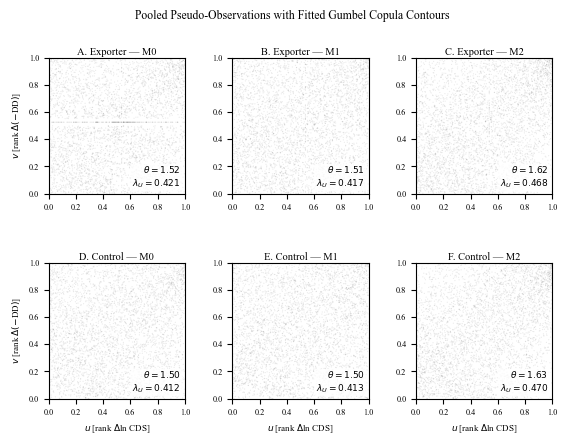

In [13]:
# ── Figure: 2×3 scatter + Gumbel contours ───────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(6.5, 4.5))
plt.subplots_adjust(hspace=0.45, wspace=0.35)

panel_labels = [['A','B','C'],['D','E','F']]
cmaps = {'Exporter': 'Blues', 'Control': 'Oranges'}

def gumbel_cdf(u, v, theta):
    lu = -np.log(np.clip(u, 1e-10, 1-1e-10))
    lv = -np.log(np.clip(v, 1e-10, 1-1e-10))
    return np.exp(-(lu**theta + lv**theta)**(1/theta))

def gumbel_density_grid(theta, n=200):
    eps = 1e-4
    g = np.linspace(eps, 1-eps, n)
    U, V = np.meshgrid(g, g)
    h = 1e-5
    # numerical density via finite differences
    C   = gumbel_cdf(U, V, theta)
    Cup = gumbel_cdf(U+h, V+h, theta)
    Cu  = gumbel_cdf(U+h, V, theta)
    Cv  = gumbel_cdf(U, V+h, theta)
    dens = (Cup - Cu - Cv + C) / (h**2)
    dens = np.clip(dens, 0, None)
    return U, V, dens

for i, (group_name, _) in enumerate(groups.items()):
    for j, model in enumerate(models):
        ax = axes[i, j]
        u, v, gfit = fits_store[(group_name, model)]

        # scatter (thin)
        ax.scatter(u, v, s=0.8, c='black', alpha=0.08, edgecolors='none', zorder=1)

        # Gumbel contour on (0,1)² unit square
        U, V, Z = gumbel_density_grid(gfit['theta'])
        ax.contour(U, V, Z, levels=7, cmap=cmaps[group_name], linewidths=0.9, alpha=0.85, zorder=2)

        label = panel_labels[i][j]
        ax.set_title(f'{label}. {group_name} — {model}', fontsize=7.5, pad=2)
        ax.text(0.97, 0.03,
                f'$\\theta={gfit["theta"]:.2f}$\n$\\lambda_U={gfit["tail_dep"]:.3f}$',
                transform=ax.transAxes, fontsize=6.5, va='bottom', ha='right',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.8))

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect('equal')
        ax.tick_params(axis='both', labelsize=6)
        if i == 1:
            ax.set_xlabel(r'$u$ [rank $\Delta$ln CDS]', fontsize=6.5)
        if j == 0:
            ax.set_ylabel(r'$v$ [rank $\Delta(-$DD$)$]', fontsize=6.5)

fig.suptitle('Pooled Pseudo-Observations with Fitted Gumbel Copula Contours',
             fontsize=8.5, fontweight='normal')

plt.savefig('../output/figures/graph_copulas.pdf', bbox_inches='tight', dpi=200)
plt.savefig('../output/figures/graph_copulas.png', bbox_inches='tight', dpi=200)
plt.show()
print('Done')

In [14]:
# ── AIC comparison table across all families ─────────────────────────────────
aic_pivot = res_df.pivot_table(index=['Group','Model'], columns='Copula', values='AIC').round(1)
aic_pivot['Best'] = aic_pivot.idxmin(axis=1)
print(aic_pivot.to_string())

Copula          Clayton      Frank  Gumbel     Best
Group    Model                                     
Control  M0         2.1  5758306.8  3507.3  Clayton
         M1         1.0  5758306.8  3478.9  Clayton
         M2      -165.3  5758306.8  1557.0  Clayton
Exporter M0        -2.8  5758306.8  3249.9  Clayton
         M1        -4.7  5758306.8  3367.4  Clayton
         M2      -171.0  5758306.8  1656.5  Clayton


In [15]:
# ── LaTeX table ─────────────────────────────────────────────────────────────
gumbel_latex = gumbel_df[['Group','Model','theta','tail_dep','AIC','Best_AIC']].copy()

latex_rows = []
for _, row in gumbel_latex.iterrows():
    best_marker = r'$^*$' if row['Best_AIC'] else ''
    latex_rows.append(
        f"{row['Group']} & {row['Model']} & {row['theta']:.3f} & {row['tail_dep']:.3f} "
        f"& {row['AIC']:.1f}{best_marker} \\\\"
    )

print(r"""\begin{table}[htbp]
\centering
\begin{tcolorbox}[
    colback=black!3, colframe=black!40, boxrule=0.4pt, arc=2pt,
    left=8pt, right=8pt, top=6pt, bottom=6pt, width=\textwidth]
\footnotesize
\begin{center}\textbf{Table X.} Gumbel Copula Fits: Upper Tail Dependence.\end{center}
\vspace{4pt}\hrule\vspace{6pt}
\begin{tabular*}{\textwidth}{@{\extracolsep{\fill}} llccc}
\toprule
Group & Model & $\\theta$ & $\\lambda_U = 2-2^{1/\\theta}$ & AIC \\\\
\\midrule""")
for r in latex_rows:
    print(r)
print(r"""\bottomrule
\end{tabular*}
\vspace{6pt}\hrule\vspace{4pt}
\footnotesize
\textit{Note:} Gumbel copulas fitted by MLE to pooled pseudo-uniform pairs 
$(u,v) = (\\text{rank}(\\Delta\\ln\\text{CDS}), \\text{rank}(\\Delta(-\\text{DD})))$, 
pooled across all country-weeks within each group. $\\lambda_U$ is the upper tail 
dependence coefficient. $^*$ indicates preferred family by AIC among Gumbel, Clayton, Frank.
\end{tcolorbox}
\caption{Gumbel copula parameter estimates and upper tail dependence by group and model.}
\label{tab:copula_gumbel}
\end{table}""")

\begin{table}[htbp]
\centering
\begin{tcolorbox}[
    colback=black!3, colframe=black!40, boxrule=0.4pt, arc=2pt,
    left=8pt, right=8pt, top=6pt, bottom=6pt, width=\textwidth]
\footnotesize
\begin{center}\textbf{Table X.} Gumbel Copula Fits: Upper Tail Dependence.\end{center}
\vspace{4pt}\hrule\vspace{6pt}
\begin{tabular*}{\textwidth}{@{\extracolsep{\fill}} llccc}
\toprule
Group & Model & $\\theta$ & $\\lambda_U = 2-2^{1/\\theta}$ & AIC \\\\
\\midrule
Exporter & M0 & 1.518 & 0.421 & 3249.9 \\
Exporter & M1 & 1.508 & 0.417 & 3367.4 \\
Exporter & M2 & 1.625 & 0.468 & 1656.5 \\
Control & M0 & 1.499 & 0.412 & 3507.3 \\
Control & M1 & 1.502 & 0.413 & 3478.9 \\
Control & M2 & 1.630 & 0.470 & 1557.0 \\
\bottomrule
\end{tabular*}
\vspace{6pt}\hrule\vspace{4pt}
\footnotesize
\textit{Note:} Gumbel copulas fitted by MLE to pooled pseudo-uniform pairs 
$(u,v) = (\\text{rank}(\\Delta\\ln\\text{CDS}), \\text{rank}(\\Delta(-\\text{DD})))$, 
pooled across all country-weeks within each group. $\\lamb

In [16]:
mask = df[COUNTRY_COL].isin(EXPORTERS)
sub  = df.loc[mask, ['dln_cds', 'd_neg_dd_M0']].dropna()
print(sub.corr())
print(sub.describe())

              dln_cds  d_neg_dd_M0
dln_cds      1.000000     0.043354
d_neg_dd_M0  0.043354     1.000000
           dln_cds  d_neg_dd_M0
count  4168.000000  4168.000000
mean     -0.000203     0.002584
std       0.076667     0.471224
min      -0.511164   -10.938521
25%      -0.033572    -0.008999
50%      -0.000456    -0.000000
75%       0.027128     0.007422
max       0.826262    12.766444
